In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [4]:
! pip install --user -v CLUEstering


Using pip 24.0 from /usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pip (python 3.11)
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 8.5 MB/s eta 0:00:00m eta 0:00:010:00:01
  Running command pip subprocess to install build dependencies
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB ? eta -:--:--
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB 1.4 MB/s eta 0:00:01
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.1 MB 954.3 kB/s eta 0:00:02
     ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.1 MB 1.1 MB/s eta 0:00:01
     ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 0.5/1.1 MB 2.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━

In [4]:
import CLUEstering

CLUE executed in 491.632062 ms
Number of clusters found: 3


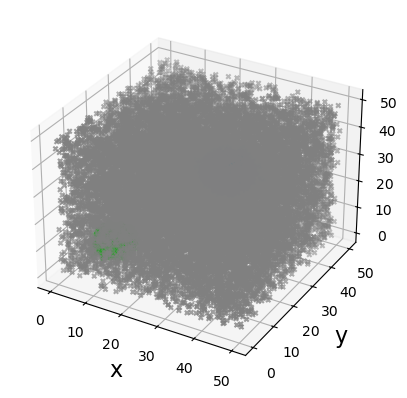

In [8]:
import numpy as np
import pandas as pd
import sys
import CLUEstering as clue

# 1. Define how many points belong to clusters vs noise
n_points = 100000
n_cluster_points = 40000  # 40k points in two blobs
n_noise_points = 20000    # 20k random points

# 2. Generate Cluster A (Centered at 10, 10, 10)
cluster_a = np.random.normal(loc=10.0, scale=1.5, size=(n_cluster_points, 3))

# 3. Generate Cluster B (Centered at 30, 30, 30)
cluster_b = np.random.normal(loc=30.0, scale=2.0, size=(n_cluster_points, 3))

# 4. Generate Random Noise
noise = np.random.uniform(low=0, high=50, size=(n_noise_points, 3))

# 5. Combine and shuffle to reach exactly 100,000 points
data = np.vstack([cluster_a, cluster_b, noise])
np.random.shuffle(data)

# CLUEstering expects data in form: [[x0, ...], [y0, ...], ..., [w0, ...]]
# We need to add weights and transpose the array
weights = np.ones(data.shape[0])
input_data = np.column_stack((data, weights)).T

clusterer = clue.clusterer(1., 5.)
clusterer.read_data(input_data)
clusterer.run_clue(backend='gpu cuda', verbose=True)
clusterer.cluster_plotter()


In [4]:
from primary.clue import run_clue_hybrid
import torch
from primary.calibration import CALIBRATION
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_maskv3(particles, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)
event_id = 5
calo = calo_hits.filter(pl.col('event_id')<= event_id)
# create mappings between calo hits particle id and their target particle ids
from primary.preprocessing import backtrack_to_target
calo_deps_particles = (
    calo.lazy()
    .select('contrib_particle_ids', 'event_id')
    .explode('contrib_particle_ids')
    .explode('contrib_particle_ids')
    .rename({'contrib_particle_ids': 'particle_id'})
    .unique()
)
target_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle', 'vertex_primary')
    .explode('particle_id','is_target_particle','vertex_primary')
    .filter(pl.col('is_target_particle') & (pl.col('event_id') <= event_id) & (pl.col('vertex_primary') == 1))
)


Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 9397289 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [5]:
calo_deps_mappings = backtrack_to_target(particles, calo_deps_particles, target_particles)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [6]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from primary.calibration import CALIBRATION
from primary.clustering import execute, metric_eval

# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------
event_id_until = 3
calo = calo_hits.filter(pl.col('event_id') <= event_id_until)

# Process Data: Explode -> Calibrate -> Group Back -> Pad
# This preserves the (Batch, Points) structure
data_processed = (
    calo.lazy()
    .select(['event_id', 'x', 'y', 'z', 'total_energy', 'detector'])
    .explode(['x', 'y', 'z', 'total_energy', 'detector'])
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')* 1000).alias('energy'))
    .group_by('event_id', maintain_order=True)
    .agg([
        pl.col('x'), pl.col('y'), pl.col('z'), pl.col('energy'), pl.col('detector')
    ])
    .sort('event_id')
    .collect()
)

points_list = []
features_list = []

# Iterate and convert to Tensors
for row in data_processed.iter_rows(named=True):
    # Shape: (N_hits, 4) - x, y, z, energy
    # instead of energy, add ones as features for now
    ones = np.ones_like(row['x'])
    #p = np.column_stack([row['x'], row['y'], row['z'], row['energy']])
    p = np.column_stack([row['x'], row['y'], row['z'], row['energy']])
    points_list.append(torch.tensor(p, dtype=torch.float32))
    

In [26]:

import CLUEstering as clue
#'dc': 105.29947637865176, 'dm': 207.87708279592312, 'rhoc': 0.41209239491050614, 'max_neighbors': 300
#dc - 45.97769115408347, 'dm': 70.16613717473524, 'rhoc': 0.17722605917818973
#clusterer = clue.clusterer(dc=45.977, rhoc=177, dm=70.166)
clusterer = clue.clusterer(dc=100.977, rhoc=100, dm=120.166, ppbin=16)



In [28]:

clusterer.read_data(points_list[0].T.numpy())
clusterer.run_clue(backend='gpu cuda', verbose=True, block_size=1024)
#clusterer.cluster_plotter()


CLUE executed in 577.286896 ms
Number of clusters found: 2014


In [29]:
calo = calo.filter(pl.col('event_id') == 0)

In [30]:
centroids = clusterer.cluster_centroids()

[[255]
 [436]
 [ 10]
 ...
 [236]
 [  5]
 [  4]]


In [31]:
centroids[:,0].reshape(1,-1)
cent_x = np.zeros_like(clusterer.cluster_ids,dtype=np.float32)
cent_y = np.zeros_like(clusterer.cluster_ids,dtype=np.float32)
cent_z = np.zeros_like(clusterer.cluster_ids,dtype=np.float32)
for i in range(len(clusterer.cluster_ids)):
    cluster_id = clusterer.cluster_ids[i]
    if cluster_id != -1:  # Ignore noise points
        cent_x[i] = centroids[cluster_id, 0]
        cent_y[i] = centroids[cluster_id, 1]
        cent_z[i] = centroids[cluster_id, 2]
    else:
        cent_x[i] = float('inf')  # Or some other value to indicate noise
        cent_y[i] = float('inf')
        cent_z[i] = float('inf')

In [12]:
calo= calo.with_columns([
        pl.Series(name='cluster_id', values=clusterer.cluster_ids.reshape(1,-1)),
        pl.Series(name='cluster_cx', values=cent_x.reshape(1,-1)),
        pl.Series(name='cluster_cy', values=cent_y.reshape(1,-1)),
        pl.Series(name='cluster_cz', values=cent_z.reshape(1,-1))
    ])

In [32]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 0), event_idx=0)

FigureWidget({
    'data': [{'customdata': array([[424, 0.22474928220617582, 0.6128708273017881,
                                    '<b>p</b> (PDG:2212) ID:187789: <b>0.1377 GeV</b><br><b>p</b> (PDG:2212) ID:160406: <b>0.087 GeV</b>'],
                                   [1341, 1.0081246867775917, 1.0,
                                    '<b>p</b> (PDG:2212) ID:186515: <b>0.8805 GeV</b><br><b>p</b> (PDG:2212) ID:186520: <b>0.1276 GeV</b>'],
                                   [161, 2.3526526470504905, 0.7732574297645796,
                                    '<b>e-</b> (PDG:11) ID:187958: <b>0.7648 GeV</b><br><b>e+</b> (PDG:-11) ID:187959: <b>0.2812 GeV</b><br><b>e-</b> (PDG:11) ID:187964: <b>0.2531 GeV</b><br><b>e-</b> (PDG:11) ID:187962: <b>0.2428 GeV</b><br><b>e-</b> (PDG:11) ID:187963: <b>0.1378 GeV</b>'],
                                   ...,
                                   [1836, 5.983166304486076, 0.85522319842669,
                                    '<b>e-</b> (PDG:11) ID:187

In [49]:
calo

event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times,cluster_id,cluster_cx,cluster_cy,cluster_cz
u32,list[u8],list[f32],list[f32],list[f32],list[f32],list[list[u64]],list[list[f32]],list[list[f32]],"array[i32, 669672]","array[f64, 6665]","array[f64, 6665]","array[f64, 6665]"
0,"[9, 10, … 12]","[0.000816, 0.000229, … 0.001104]","[202.36615, 142.800003, … -426.024139]","[296.12851, -1333.199951, … -383.597717]","[-3308.449951, 1071.0, … -3698.5]","[[140074], [176808], … [101665]]","[[0.000816], [0.000229], … [0.001104]]","[[11.255494], [6.272169], … [12.511644]]","[831, 731, … 4102]","[-398.742391, 490.346629, … 999.584901]","[-1095.918701, 1161.589925, … 69.563266]","[-3306.766602, -2599.300049, … -3251.034061]"


In [33]:
(calo.lazy().select('contrib_particle_ids', 'contrib_energies', 'event_id', 'cluster_id', 'detector')
    .explode('contrib_particle_ids', 'contrib_energies', 'cluster_id', 'detector')
    .explode('contrib_particle_ids', 'contrib_energies')
    .rename({'contrib_particle_ids':'particle_id', 'contrib_energies':'energy_contribution'})
    # Calibrate energy contributions
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('energy_contribution') * pl.col('calib_factor')).alias('energy_contribution'))
    .join(
        particles.lazy()
        .filter(pl.col('event_id')==0)
        .select('event_id', 'particle_id','vertex_primary')
        .explode('particle_id','vertex_primary'), on=['event_id','particle_id'], how='inner'

    )
    .join(calo_deps_mappings.lazy(),
            left_on=['event_id','particle_id'], right_on=['event_id','src_particle_id'], how='inner'
        )
    .filter(pl.col('target_particle_id').is_not_null())
    #.filter(pl.col('vertex_primary')==1)
    .with_columns(pl.when(pl.col('vertex_primary') == 1).then(1).otherwise(0).alias('hard_scatter'))
    # two classes: cluster_id == -1 (noise), cluster_id != -1 (signal)
    .with_columns(pl.when(pl.col('cluster_id') == -1).then(0).otherwise(1).alias('is_signal'))
    .group_by('is_signal', 'event_id', 'hard_scatter')
    .agg(pl.col('energy_contribution').sum().alias('primary_energy_contribution'))
    # do ratio

    ).collect()

is_signal,event_id,hard_scatter,primary_energy_contribution
i32,u32,i32,f64
0,0,1,3.551905
1,0,1,1057.967047


In [15]:
# Calculate noise accumulated energy and signal clusters accumulated energy

from primary.calibration import CALIBRATION

# Explode calo to get per-hit data
exploded = (
    calo.lazy()
    .select('total_energy', 'detector', 'cluster_id')
    .explode('total_energy', 'detector', 'cluster_id')
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('calibrated_energy'))
)

# Group by cluster_id and sum calibrated energies
energy_per_cluster = (
    exploded
    .group_by('cluster_id')
    .agg(pl.col('calibrated_energy').sum().alias('total_energy'))
    .collect()
)

# Noise accumulated energy (cluster_id == -1)
noise_energy = energy_per_cluster.filter(pl.col('cluster_id') == -1)['total_energy'].sum()

# Signal clusters accumulated energy (cluster_id != -1)
signal_clusters_energy = energy_per_cluster.filter(pl.col('cluster_id') != -1)

# Sum all signal clusters together
total_signal_energy = signal_clusters_energy['total_energy'].sum()

print(f"Noise accumulated energy: {noise_energy}")
print(f"Total signal clusters accumulated energy: {total_signal_energy}")

Noise accumulated energy: 65.31283444227265
Total signal clusters accumulated energy: 18662.902785166276


In [10]:
# Force full memory release
import gc
import torch

# Delete all large objects
try:
    del clusterer
except NameError:
    pass

try:
    del points_list
except NameError:
    pass

try:
    del data_processed
except NameError:
    pass

# Clear all variables from namespace (be careful!)
# for name in dir():
#     if not name.startswith('_'):
#         del globals()[name]

# Force garbage collection
gc.collect()

# Clear PyTorch caches
torch.cuda.empty_cache()
torch.cuda.synchronize()  # Wait for all operations to complete

print("Memory cleanup complete. Check nvidia-smi.")

Memory cleanup complete. Check nvidia-smi.
